In [1]:
import os, sys
import pandas as pd
import numpy as np
from SALib.sample import saltelli
from SALib.analyze import sobol
from SALib.sample import morris as morris_sample
from SALib.analyze import morris
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Input, Conv2D, Flatten, Dense, LSTM, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.layers import MultiHeadAttention, Dropout, Add, Reshape, Lambda, TimeDistributed
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback, ModelCheckpoint
import logging
import optuna

src_path = os.getcwd()
while '.venv' not in os.listdir(src_path):
    src_path =  os.path.dirname(src_path)
display(src_path)

sys.path.append(os.path.join(src_path,'src','models'))

from model_preprocessing import RegressionPreprocess as prepro

cwd = os.getcwd()

'C:\\Users\\Utilisateur\\Desktop\\doctorat\\2. Recherche\\Article 1\\3. Python\\PhD_article_1'

In [2]:
class ANN():
    def model_build(self, input_shape, mod_type, filters: int = 32, kernel_size: slice =(3,3), 
                    hidden_units: int = 32, num_layers: int = 1, num_layers_Conv: int = 1, hidden_units_LSTM: int = 16, 
                    num_layers_LSTM: int = 1, batch_size: int = 32, epochs: int = 100, **kwargs):
        """
        Building and compiling CNN 2D model.

        Args:
            input_shape (tuple): Dimensions de l'entrée (hauteur, largeur, canaux).

        Returns:
            model (tf.keras.Model): Compiled CNN 2D model.
        """
        if mod_type == 'CNN_LSTM':
            input_model = Input(shape=input_shape)
            input_model = Reshape((input_shape[0], input_shape[1], 1))(input_model)
            x = Conv2D(filters=filters, kernel_size=kernel_size, activation='relu')(input_model)
            for _ in range(num_layers_Conv - 1):
                if input_shape[1] < 10:
                    s = (3,1)
                else:
                    s = (3,3)
                x = Conv2D(filters=filters//2, kernel_size=s, activation='relu')(x)

            x = TimeDistributed(Flatten())(x)

            x = LSTM(units=hidden_units_LSTM, return_sequences=True, dropout=0.2)(x)
            for _ in range(num_layers_LSTM - 1):
                x = LSTM(units=hidden_units_LSTM, dropout=0.2)(x)

            x = Flatten()(x)

            for _ in range(num_layers - 1):
                x = Dense(units=hidden_units, activation='relu')(x)


        pred_output = Dense(units=100, activation='tanh', name='pred')(x)

        model = Model(inputs=input_model, outputs={'pred': pred_output})

        model.compile(optimizer=Adam(learning_rate=1e-4, clipnorm=1.0), loss='mean_squared_error', metrics=['mse','mae',self.sign_accuracy])

        return model

    def sign_accuracy(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        # Compare les signes : True si les signes sont identiques
        same_sign = tf.equal(tf.sign(y_true), tf.sign(y_pred))

        return tf.reduce_mean(tf.cast(same_sign, tf.float32))

In [3]:
def load_optuna_config():
        optuna.logging.get_logger("optuna").addHandler(logging.StreamHandler(sys.stdout))
        STUDY_NAME = 'FR0000073272_OHLCV_FOB_CNN_LSTM_optuna_study'
        DB_PATH = os.path.join(cwd, 'FR0000073272_OHLCV_FOB_CNN_LSTM_optimization.log')
        storage = optuna.storages.JournalStorage(
            optuna.storages.journal.JournalFileBackend(DB_PATH),
        )
        return STUDY_NAME, DB_PATH, storage
    
STUDY_NAME, DB_PATH, storage = load_optuna_config()
dict_params = optuna.load_study(storage=storage, study_name=STUDY_NAME).best_params
display(dict_params)

C:\Users\Utilisateur\anaconda3\lib\site-packages\optuna\distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [3, 3] which is of type list.
  warnings.warn(message)
C:\Users\Utilisateur\anaconda3\lib\site-packages\optuna\distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [5, 5] which is of type list.
  warnings.warn(message)
C:\Users\Utilisateur\anaconda3\lib\site-packages\optuna\distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [7, 7] which is of type list.
  warnings.warn(message)


{'filters': 32,
 'kernel_size': [5, 5],
 'hidden_units': 256,
 'num_layers': 1,
 'num_layers_Conv': 2,
 'hidden_units_LSTM': 32,
 'num_layers_LSTM': 2,
 'batch_size': 32,
 'epochs': 100}

In [4]:
model = ANN().model_build(input_shape = (100,269), mod_type = 'CNN_LSTM', **dict_params)

model.load_weights('FR0000073272_OHLCV_FOB_CNN_LSTM.h5')
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 100, 269, 1)]     0         
                                                                 
 conv2d (Conv2D)             (None, 96, 265, 32)       832       
                                                                 
 conv2d_1 (Conv2D)           (None, 94, 263, 16)       4624      
                                                                 
 time_distributed (TimeDist  (None, 94, 4208)          0         
 ributed)                                                        
                                                                 
 lstm (LSTM)                 (None, 94, 32)            542848    
                                                                 
 lstm_1 (LSTM)               (None, 32)                8320      
                                                             

In [5]:
df = pd.read_parquet(os.path.join(cwd, 'FR0000073272_features.parquet.gzip'))

X_data, Y_data, _, _, _ = prepro().preprocessing(data=df, data_type = 'OHLCV_FOB')
display(X_data.shape)
X_test, Y_test = X_data[int(0.8*len(X_data)):], Y_data[int(0.8*len(Y_data)):]
display(X_test.shape)
X = X_test[0]
display(X.shape)

Execution preprocessing : 		Preprocessing FOB for models.
Execution create_target : 		Creating Y True.
create_target : 		Creating Y True Done.
Execution scaling : 		Scaling data.


C:\Users\Utilisateur\Desktop\doctorat\2. Recherche\Article 1\3. Python\PhD_article_1\src\models\model_preprocessing.py:89: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[f'target_{i+1}'] = data['Close'].shift(-i)
C:\Users\Utilisateur\Desktop\doctorat\2. Recherche\Article 1\3. Python\PhD_article_1\src\models\model_preprocessing.py:89: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[f'target_{i+1}'] = data['Close'].shift(-i)
C:\Users\Utilisateur\Desktop\doctorat\2. Recherche\Article 1\3. Python\PhD_article_1\src\models\mode

scaling : 		Scaling data Done.
Execution prepare_sequences : 		Preparing the sequences.
prepare_sequences : 		Preparing the sequences Done.
preprocessing : 		Preprocessing FOB for models Done.


(1987, 100, 269)

(398, 100, 269)

(100, 269)

In [6]:
col_name = [c for c in df.reset_index().columns if (('price' not in c) & ('target' not in c))]
col_id = [df.reset_index().columns.get_loc(col) for col in col_name]

In [7]:
problem = {
    'num_vars': len(col_name),
    'names': col_name,
    'bounds': [[-1, 1]] * len(col_name)
}

param_values = morris_sample.sample(problem, N=10, num_levels=4)

In [8]:
def run_model(sample, X_samp, r):
    for i, v in zip(col_id, sample):
        X_samp[r,i] = v
    
    X_samp = X_samp.reshape(1, X_samp.shape[0], X_samp.shape[1], 1)
    
    return model.predict(X_samp, verbose=0)['pred']

In [9]:
Y = []
for row in range(10):
    display(row)
    Y.append(np.array([run_model(params, X, row) for params in param_values]))

0

1

2

3

4

5

6

7

8

9

In [10]:
display(Y.shape, param_values.shape)

AttributeError: 'list' object has no attribute 'shape'

In [11]:
res = pd.DataFrame()

for r, Y_r in enumerate(Y):
    for t in range(Y_r.shape[2]):
        # Analyse de Morris
        Si = morris.analyze(problem, param_values, Y_r[:,:,t])
        tmp = pd.DataFrame(Si)
        tmp['row'] = r
        tmp['target'] = t
        res = pd.concat([res, tmp])

In [12]:
display(res)

,names,mu,mu_star,sigma,mu_star_conf,row,target
0,index,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0
1,Open,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0
2,High,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0
3,Low,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0
4,Close,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0
...,...,...,...,...,...,...,...
139,buy_Market_Valid for Uncrossing_size,-1.047738e-09,2.165325e-09,3.196655e-09,1.511427e-09,9,99
140,sell_Limit_Valid for Closing_size,-1.396984e-10,2.235174e-09,3.239611e-09,1.233462e-09,9,99
141,sell_Limit_Valid for Uncrossing_size,1.117587e-09,1.396984e-09,2.401657e-09,1.326526e-09,9,99
142,sell_Market_Valid for Closing_size,2.793968e-10,1.396984e-09,2.985321e-09,1.439171e-09,9,99


In [13]:
#res = res[res['mu'] != 0]
df_res = res.groupby(['names','row'], as_index=False).mean()
display(df_res)

,names,row,mu,mu_star,sigma,mu_star_conf,target
0,Close,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,49.5
1,Close,1,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,49.5
2,Close,2,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,49.5
3,Close,3,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,49.5
4,Close,4,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,49.5
...,...,...,...,...,...,...,...
1435,total_liquidity,5,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,49.5
1436,total_liquidity,6,-3.536116e-12,2.178203e-09,2.851986e-09,1.057858e-09,49.5
1437,total_liquidity,7,-1.571607e-11,2.145593e-09,2.976135e-09,1.215707e-09,49.5
1438,total_liquidity,8,-1.797744e-10,2.668588e-09,3.376429e-09,1.259394e-09,49.5


names,index,Open,High,Low,Close,Volume,buy_size_1,sell_size_1,buy_size_2,sell_size_2,...,buy_CO_size,sell_CO_size,buy_Limit_Valid for Closing_size,buy_Limit_Valid for Uncrossing_size,buy_Market_Valid for Closing_size,buy_Market_Valid for Uncrossing_size,sell_Limit_Valid for Closing_size,sell_Limit_Valid for Uncrossing_size,sell_Market_Valid for Closing_size,sell_Market_Valid for Uncrossing_size
row,,,,,,,,,,,,,,,,,,,,,
0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
3,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
4,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
5,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
6,2.273810e-09,1.690569e-09,1.417851e-09,2.029032e-09,1.726672e-09,1.913344e-09,1.703927e-09,1.981665e-09,1.853143e-09,1.627835e-09,...,2.205139e-09,2.113680e-09,2.499204e-09,1.917186e-09,2.315850e-09,2.021261e-09,1.753127e-09,2.192653e-09,1.966604e-09,1.601817e-09
7,1.569948e-09,1.950059e-09,1.783643e-09,1.823893e-09,1.983979e-09,2.220768e-09,1.891560e-09,1.645298e-09,2.006811e-09,2.366447e-09,...,2.009649e-09,1.880078e-09,2.049419e-09,1.338922e-09,1.983979e-09,1.881912e-09,1.369001e-09,1.775436e-09,1.572567e-09,2.182351e-09
8,2.144239e-09,1.923298e-09,2.101937e-09,1.792549e-09,1.954511e-09,2.313493e-09,2.049157e-09,2.074608e-09,2.230372e-09,1.947003e-09,...,2.396569e-09,2.116343e-09,2.307337e-09,2.135377e-09,2.490167e-09,1.990571e-09,1.993889e-09,1.891036e-09,1.969573e-09,2.019471e-09


<Axes: xlabel='names', ylabel='row'>

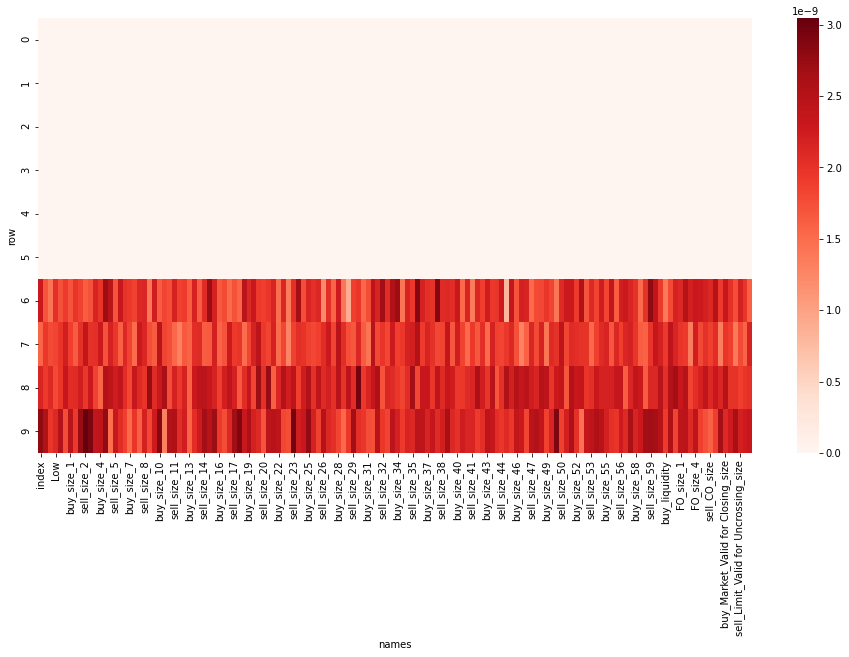

In [14]:
pivot_table = df_res.pivot(index='row', columns='names', values='mu_star')[col_name]
display(pivot_table)

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 8))
sns.heatmap(pivot_table, cmap="Reds")

In [15]:
display(pivot_table[[c for c in pivot_table.columns if 'buy' in c]].mean().mean())
display(pivot_table[[c for c in pivot_table.columns if 'sell' in c]].mean().mean())

8.282133915098105e-10

8.328541297929983e-10

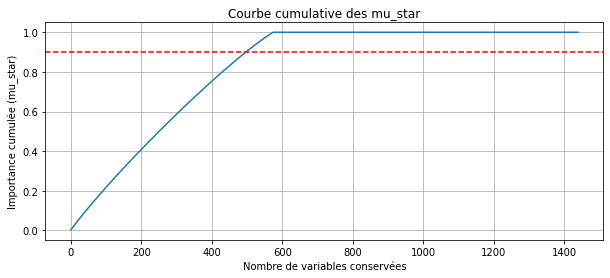

In [16]:
results_sorted = df_res.sort_values(by='mu_star', ascending=False).reset_index(drop=True)

# Courbe cumulative
results_sorted['cumulative'] = results_sorted['mu_star'].cumsum() / results_sorted['mu_star'].sum()

# Visualisation
plt.figure(figsize=(10,4))
plt.plot(results_sorted.index, results_sorted['cumulative'])
plt.axhline(y=0.9, color='r', linestyle='--')
plt.xlabel("Nombre de variables conservées")
plt.ylabel("Importance cumulée (mu_star)")
plt.title("Courbe cumulative des mu_star")
plt.grid()
plt.show()

In [17]:
display(results_sorted[:50])

,names,row,mu,mu_star,sigma,mu_star_conf,target,cumulative
0,sell_size_2,9,-3.145833e-10,3.046560e-09,3.820210e-09,1.419659e-09,49.5,0.002547
1,sell_size_23,9,-4.151661e-11,2.967499e-09,3.749814e-09,1.228525e-09,49.5,0.005027
2,buy_size_30,8,3.653986e-11,2.960951e-09,3.752652e-09,1.346238e-09,49.5,0.007503
3,buy_size_3,9,-7.011113e-11,2.912973e-09,3.682878e-09,1.196527e-09,49.5,0.009938
4,buy_size_50,9,-3.436144e-10,2.896428e-09,3.633933e-09,1.443256e-09,49.5,0.012359
5,buy_size_18,9,-2.455199e-10,2.882414e-09,3.589913e-09,1.280270e-09,49.5,0.014768
6,buy_size_38,6,-3.124005e-10,2.866436e-09,3.218174e-09,9.870611e-10,49.5,0.017165
7,buy_size_36,6,-1.811713e-11,2.865345e-09,3.566410e-09,1.157188e-09,49.5,0.019560
8,buy_size_10,9,-1.039007e-11,2.855697e-09,3.578032e-09,1.208404e-09,49.5,0.021947
9,sell_size_59,6,1.168228e-10,2.795539e-09,3.496525e-09,1.189685e-09,49.5,0.024284


In [58]:
len_p = len(results_sorted[:50])
names_p = results_sorted.loc[:49,['names','row']].apply(lambda x: '_'.join(x.astype(str)), axis=1).to_list()

problem = {
    'num_vars': len_p,
    'names': names_p,
    'bounds': [[-1, 1]] * len_p
}

param_values = saltelli.sample(problem, 128, calc_second_order=False)

In [59]:
col_id_s = [df.reset_index().columns.get_loc(col) for col in results_sorted[:50]['names']]
results_sorted['col'] = 0
results_sorted.loc[:49,'col'] = col_id_s

In [20]:
display(results_sorted[:50])

,names,row,mu,mu_star,sigma,mu_star_conf,target,cumulative,col
0,sell_size_2,9,-3.145833e-10,3.046560e-09,3.820210e-09,1.419659e-09,49.5,0.002547,13
1,sell_size_23,9,-4.151661e-11,2.967499e-09,3.749814e-09,1.228525e-09,49.5,0.005027,97
2,buy_size_30,8,3.653986e-11,2.960951e-09,3.752652e-09,1.346238e-09,49.5,0.007503,123
3,buy_size_3,9,-7.011113e-11,2.912973e-09,3.682878e-09,1.196527e-09,49.5,0.009938,15
4,buy_size_50,9,-3.436144e-10,2.896428e-09,3.633933e-09,1.443256e-09,49.5,0.012359,203
5,buy_size_18,9,-2.455199e-10,2.882414e-09,3.589913e-09,1.280270e-09,49.5,0.014768,75
6,buy_size_38,6,-3.124005e-10,2.866436e-09,3.218174e-09,9.870611e-10,49.5,0.017165,155
7,buy_size_36,6,-1.811713e-11,2.865345e-09,3.566410e-09,1.157188e-09,49.5,0.019560,147
8,buy_size_10,9,-1.039007e-11,2.855697e-09,3.578032e-09,1.208404e-09,49.5,0.021947,43
9,sell_size_59,6,1.168228e-10,2.795539e-09,3.496525e-09,1.189685e-09,49.5,0.024284,241


In [60]:
def run_model_s(param, X_samp, data):
    for i, row in data.iterrows():
        X_samp[row['row'], row['col']] = param[i]
    
    X_samp = X_samp.reshape(1, X_samp.shape[0], X_samp.shape[1], 1)
    
    return model.predict(X_samp, verbose=0)['pred']

Y = np.array([run_model_s(params, X, results_sorted[:50]) for params in param_values])

In [68]:
res = pd.DataFrame()

#for t in range(Y.shape[2]):
for t in range(4):
    display(t)
    Si = sobol.analyze(problem, Y[:,:,t].reshape(Y.shape[0]), calc_second_order=False)

    tmp = pd.concat(Si.to_df(), axis=1)
    tmp['target'] = t
    res = pd.concat([res,tmp])

0

1

2

3

index,Close,Open,buy_Limit_Valid for Uncrossing_size,buy_size_10,buy_size_15,buy_size_18,buy_size_19,buy_size_2,buy_size_20,buy_size_21,...,sell_size_29,sell_size_32,sell_size_33,sell_size_35,sell_size_4,sell_size_51,sell_size_52,sell_size_57,sell_size_59,total_liquidity
row,,,,,,,,,,,,,,,,,,,,,
6,NaN,NaN,NaN,NaN,0.921273,NaN,NaN,NaN,NaN,NaN,...,NaN,1.049248,1.058767,NaN,0.960642,NaN,0.969421,NaN,0.920297,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.980759,0.976484,...,NaN,NaN,NaN,0.949203,NaN,0.976294,NaN,NaN,NaN,0.974405
9,0.92077,0.893278,0.845659,0.962921,NaN,1.002655,0.954994,0.983012,NaN,NaN,...,0.988716,NaN,NaN,NaN,1.009931,0.929242,NaN,0.977576,0.914165,NaN


<Axes: xlabel='index', ylabel='row'>

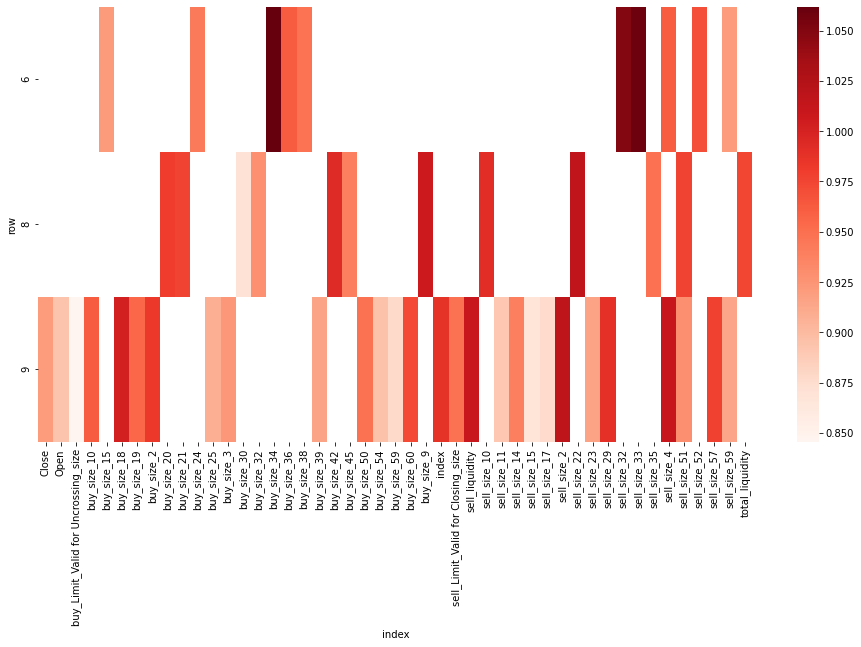

In [75]:
df_res_ST = res.reset_index().groupby(['index'], as_index=False).mean()

df_res_ST['row'] = df_res_ST['index'].apply(lambda x: x.split('_')[-1])
df_res_ST['index'] = df_res_ST['index'].apply(lambda x: '_'.join(x.split('_')[:-1]))
df_res_ST = df_res_ST.sort_values('index')
pivot_table = df_res_ST.pivot(index='row', columns='index', values='ST')
display(pivot_table)

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 8))
sns.heatmap(pivot_table, cmap="Reds")

In [69]:
display(res)

,ST,ST_conf,S1,S1_conf,target
sell_size_2_9,0.978749,0.193446,-0.018229,0.246996,0
sell_size_23_9,0.894055,0.202699,-0.034214,0.230870,0
buy_size_30_8,0.931915,0.223233,0.098751,0.241066,0
buy_size_3_9,1.011841,0.200306,0.129495,0.237362,0
buy_size_50_9,1.068210,0.216998,0.105903,0.232140,0
...,...,...,...,...,...
buy_size_45_8,0.842210,0.202871,-0.055061,0.193692,3
Open_9,0.941759,0.176985,-0.002423,0.280170,3
Close_9,0.839567,0.170781,0.004625,0.261417,3
sell_size_22_8,0.903878,0.139877,0.033917,0.290394,3
